In [1]:
pip install yfinance pandas numpy scikit-learn matplotlib tensorflow


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install keras


In [5]:
pip install tensorflow


  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.32.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.6/331.9 MB 8.4 MB/s eta 0:00:40
   ---------------------------------------- 2.9/331.9 MB 8

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


In [7]:
stock_symbol = 'HDFCBANK.NS'   # NSE India ticker
df = yf.download(stock_symbol, start='2015-01-01', end='2025-09-29')

C:\Users\vysha\AppData\Local\Temp\ipykernel_18920\3507566862.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start='2015-01-01', end='2025-09-29')
[*********************100%***********************]  1 of 1 completed


In [8]:
# Save data to CSV
df.to_csv('hdfcbank.csv')

In [9]:
# 2. Data Preprocessing
# Use the 'Close' column as target variable for LSTM model
data = df['Close'].values.reshape(-1, 1)

In [10]:
# Normalize the data using MinMaxScaler (scale values between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [11]:
# Define the length of the training data (80% of total data)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

In [12]:
# Split the data into training and testing sets
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len - 70:, :]


In [13]:
# Create x_train and y_train datasets
x_train = []
y_train = []

In [14]:
for i in range(70, len(train_data)):
    x_train.append(train_data[i-70:i, 0])
    y_train.append(train_data[i, 0])

In [15]:
# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [16]:
# Reshape the data to 3D for LSTM (samples, time steps, features)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [17]:
# 3. Build the LSTM Model
model = Sequential()
model.add(LSTM(units=45, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=45, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

D:\anacondaaaaa\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [35]:
# Train the model
model.fit(x_train, y_train, batch_size=34, epochs=100)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0256
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0017
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0015
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0015
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0014
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0013
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - loss: 0.0012
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0013
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0012
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0011
Epoch 13/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - loss: 0.0011
Epoch 14/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - loss: 0.0011
Epoch 15/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 1

In [36]:
# Ensure look_back variable exists (your code used 70)
if 'look_back' not in globals():
    look_back = 70

# Create the test dataset (same windowing approach used in training)
test_data = scaled_data[training_data_len - look_back:, :]   # start look_back steps before test split
x_test = []
y_test = []

for i in range(look_back, len(test_data)):
    x_test.append(test_data[i - look_back:i, 0])
    y_test.append(test_data[i, 0])

# Convert to numpy arrays and reshape for LSTM
x_test = np.array(x_test)            # shape (num_samples, look_back)
y_test = np.array(y_test)            # shape (num_samples,)

x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))  # (samples, timesteps, features)

# Predict
predictions_scaled = model.predict(x_test, verbose=0)   # model output in scaled space
# If the model returns shape (n,1) this is fine; otherwise adjust accordingly.
# Inverse-transform predictions
predictions = scaler.inverse_transform(predictions_scaled).ravel()

# Inverse-transform y_test to original scale
y_test_true = scaler.inverse_transform(y_test.reshape(-1,1)).ravel()

# Compute metrics
mape = mean_absolute_percentage_error(y_test_true, predictions) * 100
rmse = np.sqrt(mean_squared_error(y_test_true, predictions))

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Build `valid` / `result_df` aligned with dates
# The dates that correspond to y_test/predictions start at:
# index of df corresponding to training_data_len (since y_test corresponds to df rows training_data_len: )
if 'Date' in df.columns:
    # make sure df has a contiguous Date column aligned with your scaled_data
    dates = pd.to_datetime(df['Date']).reset_index(drop=True)
else:
    dates = pd.to_datetime(df.index).to_series().reset_index(drop=True)

# The test predictions correspond to rows from training_data_len to end of df
start_idx = training_data_len
dates_test = dates[start_idx: start_idx + len(predictions)].reset_index(drop=True)

# True close prices for the same dates (from original df)
actuals = df['Close']['HDFCBANK.NS'].iloc[start_idx : start_idx + len(predictions)].reset_index(drop=True)


# Create a tidy result dataframe
result_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Close": actuals,
    "Predicted_Close": predictions
})

# Optionally save result_df (change path to your Desktop if you want)
# result_df.to_csv(r"C:\Users\Aditi\Desktop\predicted_vs_actual.csv", index=False)

# Also keep the variables for later cells
valid = result_df.copy()


Mean Absolute Percentage Error (MAPE): 1.30%
Root Mean Squared Error (RMSE): 14.5163


C:\Users\vysha\AppData\Local\Temp\ipykernel_18920\3677594715.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


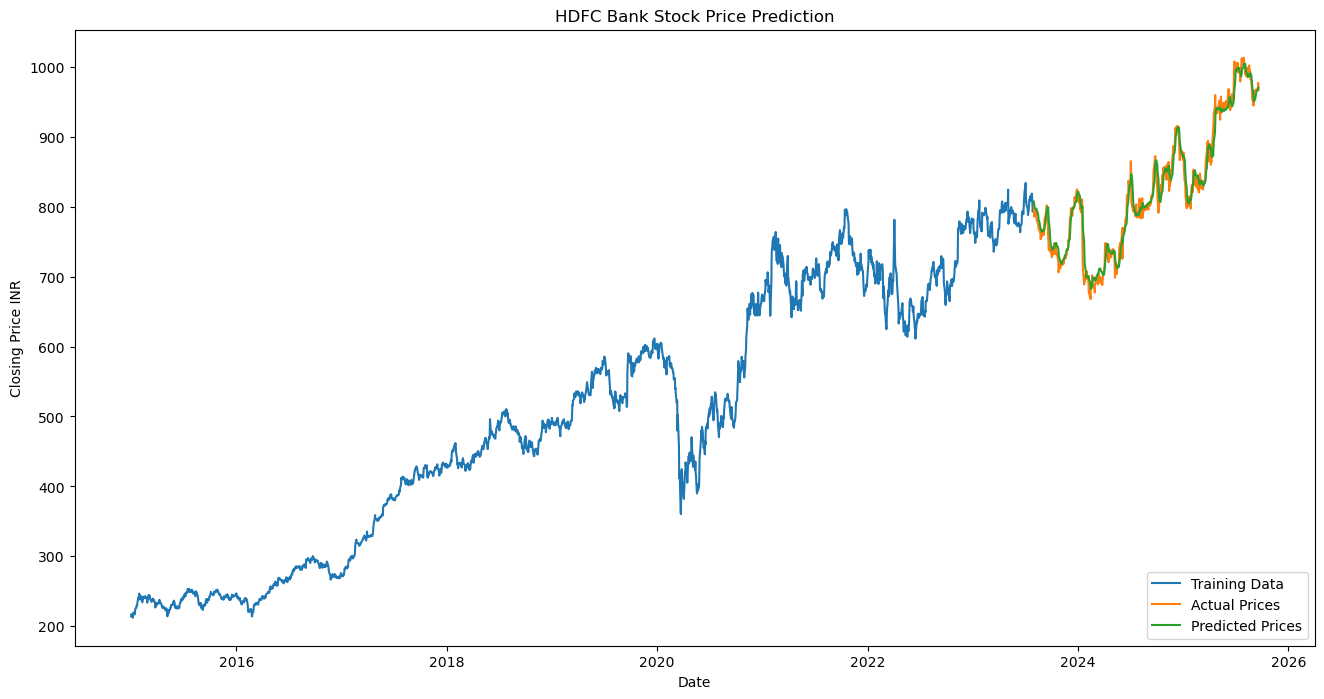

In [37]:
# 5. Plot the results
train = df[:training_data_len]
valid = df[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16, 8))
plt.title('HDFC Bank Stock Price Prediction')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Prices')
plt.plot(valid['Predictions'], label='Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price INR')
plt.legend(['Training Data', 'Actual Prices', 'Predicted Prices'], loc='lower right')
plt.show()

In [38]:
pwd

'C:\\Users\\vysha\\Downloads'

In [39]:
valid

Price,Close,High,Low,Open,Volume,Predictions
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,
Date,,,,,,
2023-08-01,802.084595,804.593724,796.173609,798.320841,35394188,807.352051
2023-08-02,791.589539,796.897362,788.042959,792.313333,28116322,805.872131
2023-08-03,785.871582,796.824977,783.145279,791.348279,57673946,802.206299
2023-08-04,797.235168,799.310069,786.161141,789.008076,37388304,797.867065
2023-08-07,796.776794,802.494757,794.991459,802.494757,28300918,797.229431
...,...,...,...,...,...,...
2025-09-15,967.049988,972.349976,965.000000,969.599976,14486377,965.809326
2025-09-16,966.849976,969.349976,961.200012,961.200012,18661794,966.841492


In [40]:
if 'Date' not in valid.columns:
    valid = valid.reset_index()

# Select only the Date, Close, and Predictions columns
result_df = valid[[ 'Date', 'Close', 'Predictions']]

result_df

Price,Date,Close,Predictions
Ticker,,HDFCBANK.NS,
0,2023-08-01,802.084595,807.352051
1,2023-08-02,791.589539,805.872131
2,2023-08-03,785.871582,802.206299
3,2023-08-04,797.235168,797.867065
4,2023-08-07,796.776794,797.229431
...,...,...,...
524,2025-09-15,967.049988,965.809326
525,2025-09-16,966.849976,966.841492
526,2025-09-17,966.500000,967.381653


In [41]:
# use your training window length (you used 70 earlier)
look_back = 70

def forecast_recursive(days):
    window = scaled_data[-look_back:].reshape(1, look_back, 1).copy()
    preds = []
    for _ in range(days):
        p_scaled = model.predict(window, verbose=0).ravel()[0]
        preds.append(p_scaled)
        window = np.append(window[:,1:,:], [[[p_scaled]]], axis=1)
    preds = np.array(preds).reshape(-1,1)
    return scaler.inverse_transform(preds).ravel()

# Forecast horizons
next_day_val  = float(forecast_recursive(1)[0])
next_week_vals = forecast_recursive(5)   # 5 trading days
next_month_vals = forecast_recursive(22) # ~22 trading days

# Build date ranges starting the day after last date in your df
if 'Date' in df.columns:
    last_date = pd.to_datetime(df['Date'].iloc[-1])
else:
    last_date = pd.to_datetime(df.index[-1])

dates_1 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=1, freq='B')
dates_5 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=5, freq='B')
dates_22 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=22, freq='B')

# Compose tidy dataframe of forecasts
df_day = pd.DataFrame({"Horizon":"Next Day", "Date":dates_1, "Predicted_Close":[next_day_val]})
df_week = pd.DataFrame({"Horizon":"Next Week", "Date":dates_5, "Predicted_Close":next_week_vals})
df_month = pd.DataFrame({"Horizon":"Next Month", "Date":dates_22, "Predicted_Close":next_month_vals})

future_forecasts = pd.concat([df_day, df_week, df_month], ignore_index=True)

# Print short summary and show table
print("Next Day:", round(next_day_val,4))
print("Next Week (5):", [round(v,4) for v in next_week_vals])
print("Next Month (22) first 5:", [round(v,4) for v in next_month_vals[:5]])

Next Day: 969.6755
Next Week (5): [969.6755, 969.8287, 969.8358, 969.7765, 969.6685]
Next Month (22) first 5: [969.6755, 969.8287, 969.8358, 969.7765, 969.6685]


In [42]:
# Save entire forecast DataFrame
future_forecasts.to_csv("C:/Users/vysha/Downloads/future_forecasts.csv", index=False)

In [43]:
# --- Fetch today's live price (intraday latest) ---
import yfinance as yf
import pandas as pd

stock_symbol = 'HDFCBANK.NS'

# Get today's 1-minute interval data
latest_data = yf.download(stock_symbol, period="1d", interval="1m")

# Extract the last available price
latest_price = float(latest_data['Close'].iloc[-1])
latest_time = latest_data.index[-1]  # includes both date and time

print(f"Latest Market Price on {latest_time}: {latest_price:.2f} INR")

# Save to CSV for Power BI
latest_price_df = pd.DataFrame({
    "DateTime": [latest_time],
    "Latest_Close": [latest_price]
})
latest_price_df.to_csv("C:/Users/vysha/Downloads/latest_price.csv", index=False)

C:\Users\vysha\AppData\Local\Temp\ipykernel_18920\3344991899.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  latest_data = yf.download(stock_symbol, period="1d", interval="1m")
[*********************100%***********************]  1 of 1 completed

Latest Market Price on 2025-09-19 09:59:00+00:00: 967.00 INR



C:\Users\vysha\AppData\Local\Temp\ipykernel_18920\3344991899.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_price = float(latest_data['Close'].iloc[-1])
